# Notebook 3 — Fine-tuning con LoRA: BERT / clinical-BERT / mT5

Skeleton único y reutilizable para los tres modelos. Para cambiar de modelo, se edita
**solo la celda de configuración** (`MODEL_KEY`) — el resto del notebook se adapta solo.

**Cambios importantes respecto al ejemplo visto en clase:**
- `target_modules` depende de la arquitectura: BERT/RoBERTa usan `query`/`value`. mT5 (arquitectura T5)
  usa `q`/`v`.
- `task_type`: Para BERT/clinical-BERT es `TOKEN_CLS`
  (clasificación de tokens / NER) y mT5 es `SEQ_2_SEQ_LM`.


## 1. Setup e imports

In [1]:
try:
    from google.colab import drive
    drive.mount("/content/drive")

except ImportError:
    SPLITS_DIR = "."

Mounted at /content/drive


In [2]:
# !pip install transformers peft datasets seqeval evaluate accelerate --quiet

import numpy as np
import torch
import random
from pathlib import Path
from datasets import load_from_disk

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    AutoModelForSeq2SeqLM,
    DataCollatorForTokenClassification,
    DataCollatorForSeq2Seq,
    TrainingArguments,
    Seq2SeqTrainingArguments,
    Trainer,
    Seq2SeqTrainer,
)
from peft import LoraConfig, get_peft_model, TaskType

random.seed(42)

# ─────────────────────────────────────────────────────────────────────────
# RUTA BASE EN GOOGLE DRIVE (Mi unidad > TopicosIA)
BASE_DIR = Path("/content/drive/MyDrive/TopicosIA")
# ─────────────────────────────────────────────────────────────────────────

SPLITS_DIR = BASE_DIR / "distemist_final"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Configuración — ÚNICO LUGAR QUE CAMBIA ENTRE MODELOS

Cambien `MODEL_KEY` a `"bert"`, `"clinical_bert"` o `"mt5"` y vuelvan a correr el notebook
completo. Ajusten los nombres de checkpoint según lo que decidieron usar (recuerden: si el
texto de DisTEMIST está en español, el "BERT clínico" debe ser un modelo clínico en
**español**, no BioClinicalBERT que es en inglés/MIMIC — como vimos antes).



In [3]:
MODEL_KEY = "mt5"  # "bert" | "clinical_bert" | "mt5"

MODEL_REGISTRY = {
    "bert": {
        "checkpoint": "dccuchile/bert-base-spanish-wwm-cased",
        "arch": "token_classification",
        "lora_target_modules": ["query", "value"],
        "lora_task_type": TaskType.TOKEN_CLS,
        "dataset": "distemist_bert_format",
    },
    "clinical_bert": {
        "checkpoint": "PlanTL-GOB-ES/roberta-base-biomedical-clinical-es",
        "arch": "token_classification",
        "lora_target_modules": ["query", "value"],
        "lora_task_type": TaskType.TOKEN_CLS,
        "dataset": "distemist_bert_format",
    },
    "mt5": {
        "checkpoint": "google/mt5-small",
        "arch": "seq2seq",
        "lora_target_modules": ["q", "v"],
        "lora_task_type": TaskType.SEQ_2_SEQ_LM,
        "dataset": "distemist_mt5_format",
    },
}

cfg = MODEL_REGISTRY[MODEL_KEY]
print(cfg)

{'checkpoint': 'google/mt5-small', 'arch': 'seq2seq', 'lora_target_modules': ['q', 'v'], 'lora_task_type': <TaskType.SEQ_2_SEQ_LM: 'SEQ_2_SEQ_LM'>, 'dataset': 'distemist_mt5_format'}


Login W&B

In [4]:
! wandb login

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: figuesicsi (figuesicsi-universidad-eafit) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 3. Cargar datos procesados del Notebook 1

Mismo split para los tres modelos — solo cambia el *formato* según la arquitectura.



In [5]:
if cfg["arch"] == "token_classification":
    raw_ds = load_from_disk(str(SPLITS_DIR / "distemist_bert_format"))
    label_list = ["O", "B-ENFERMEDAD", "I-ENFERMEDAD"]
    label2id = {l: i for i, l in enumerate(label_list)}
    id2label = {i: l for i, l in enumerate(label_list)}
else:
    raw_ds = load_from_disk(str(SPLITS_DIR / "distemist_mt5_format"))

print(raw_ds)

DatasetDict({
    train: Dataset({
        features: ['doc_id', 'input_text', 'target_text'],
        num_rows: 1668
    })
    dev: Dataset({
        features: ['doc_id', 'input_text', 'target_text'],
        num_rows: 212
    })
    test: Dataset({
        features: ['doc_id', 'input_text', 'target_text'],
        num_rows: 233
    })
})


In [6]:
print(raw_ds["dev"].column_names)
print("doc_id" in raw_ds["dev"].column_names)  # True/False directo

# y confirma que además tiene contenido real, no solo que la columna existe
print(raw_ds["dev"]["doc_id"][:5])

['doc_id', 'input_text', 'target_text']
True
['S0004-06142005000900014-1', 'es-S1139-76322014000400009-1_chunk0', 'es-S1139-76322014000400009-1_chunk1', 'es-S1139-76322014000400009-1_chunk2', 'es-S0210-56912007000900007-3_chunk0']


## 4. Tokenizador y modelo base

In [7]:
tokenizer = AutoTokenizer.from_pretrained(cfg["checkpoint"])

if cfg["arch"] == "token_classification":
    model = AutoModelForTokenClassification.from_pretrained(
        cfg["checkpoint"],
        num_labels=len(label_list),
        id2label=id2label,
        label2id=label2id,
    )
else:
    model = AutoModelForSeq2SeqLM.from_pretrained(cfg["checkpoint"])

model

config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.20GB            

...

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.20GB            

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

model.safetensors: downloading bytes:           |  0.00B            

MT5ForConditionalGeneration(
  (shared): Embedding(250112, 512)
  (encoder): MT5Stack(
    (embed_tokens): Embedding(250112, 512)
    (block): ModuleList(
      (0): MT5Block(
        (layer): ModuleList(
          (0): MT5LayerSelfAttention(
            (SelfAttention): MT5Attention(
              (q): Linear(in_features=512, out_features=384, bias=False)
              (k): Linear(in_features=512, out_features=384, bias=False)
              (v): Linear(in_features=512, out_features=384, bias=False)
              (o): Linear(in_features=384, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 6)
            )
            (layer_norm): MT5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): MT5LayerFF(
            (DenseReluDense): MT5DenseGatedActDense(
              (wi_0): Linear(in_features=512, out_features=1024, bias=False)
              (wi_1): Linear(in_features=512, out_features=1024, bias=False)
          

## 5. Tokenización / preprocesamiento según arquitectura

In [8]:
def tokenize_and_align_labels_bert(example):
    tokenized = tokenizer(example["tokens"], truncation=True, is_split_into_words=True)
    word_ids = tokenized.word_ids()
    labels = []
    previous_word_idx = None
    for word_idx in word_ids:
        if word_idx is None:
            labels.append(-100)  # ignorado en la loss
        elif word_idx != previous_word_idx:
            labels.append(label2id[example["ner_tags"][word_idx]])
        else:
            # subpalabra dentro del mismo token: mismo tag pero como I- si era B-
            tag = example["ner_tags"][word_idx]
            tag = tag.replace("B-", "I-")
            labels.append(label2id[tag])
        previous_word_idx = word_idx
    tokenized["labels"] = labels
    return tokenized


def tokenize_mt5(example):
    model_inputs = tokenizer(example["input_text"], truncation=True, max_length=512)
    labels = tokenizer(text_target=example["target_text"], truncation=True, max_length=128)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


if cfg["arch"] == "token_classification":
    tokenized_ds = raw_ds.map(tokenize_and_align_labels_bert, batched=False)
    data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)
else:
    tokenized_ds = raw_ds.map(tokenize_mt5, batched=False)
    data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

tokenized_ds

Map:   0%|          | 0/1668 [00:00<?, ? examples/s]

Map:   0%|          | 0/212 [00:00<?, ? examples/s]

Map:   0%|          | 0/233 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['doc_id', 'input_text', 'target_text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 1668
    })
    dev: Dataset({
        features: ['doc_id', 'input_text', 'target_text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 212
    })
    test: Dataset({
        features: ['doc_id', 'input_text', 'target_text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 233
    })
})

In [9]:
print(tokenized_ds["dev"].column_names)
print("doc_id" in tokenized_ds["dev"].column_names)  # True/False directo

# y confirma que además tiene contenido real, no solo que la columna existe
print(tokenized_ds["dev"]["doc_id"][:5])

['doc_id', 'input_text', 'target_text', 'input_ids', 'attention_mask', 'labels']
True
['S0004-06142005000900014-1', 'es-S1139-76322014000400009-1_chunk0', 'es-S1139-76322014000400009-1_chunk1', 'es-S1139-76322014000400009-1_chunk2', 'es-S0210-56912007000900007-3_chunk0']


## 6. Métricas comparables entre los 3 modelos

Como discutimos: BERT hace clasificación de tokens y mT5 genera texto libre, así que no se
puede comparar con la misma función "cruda". La solución es reducir la salida de **ambas**
arquitecturas al mismo formato común — **el conjunto de nombres de enfermedad detectados por
documento** — y calcular precisión/recall/F1 sobre ese conjunto. Así el número final es
comparable entre modelos aunque el mecanismo interno sea distinto.



In [10]:
# --- 1. Helpers de bajo nivel: texto/BIO -> conjunto de entidades por ejemplo ---

def strip_chunk_suffix(doc_id):
    return __import__("re").sub(r"_chunk\d+$", "", doc_id)


def bio_to_entity_set(tokens, tags):
    entities, current = [], []
    for tok, tag in zip(tokens, tags):
        if tag == "B-ENFERMEDAD":
            if current:
                entities.append(" ".join(current))
            current = [tok]
        elif tag == "I-ENFERMEDAD" and current:
            current.append(tok)
        else:
            if current:
                entities.append(" ".join(current))
            current = []
    if current:
        entities.append(" ".join(current))
    return set(e.lower().strip() for e in entities)


def mt5_output_to_entity_set(generated_text):
    if generated_text.strip().lower() == "ninguna":
        return set()
    parts = generated_text.split("[SEP]")
    return set(p.lower().strip() for p in parts if p.strip())


# --- 2. Agregación por documento original (junta los chunks de un mismo caso) ---

def aggregate_entities_by_original_doc(doc_ids, entity_sets):
    grouped = {}
    for doc_id, ents in zip(doc_ids, entity_sets):
        orig_id = strip_chunk_suffix(doc_id)
        grouped.setdefault(orig_id, set()).update(ents)
    return grouped


# --- 3. Métrica: micro-F1 sumando tp/fp/fn por documento (no un set global) ---

def entity_set_prf1(true_entities, pred_entities):
    tp = len(true_entities & pred_entities)
    fp = len(pred_entities - true_entities)
    fn = len(true_entities - pred_entities)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"precision": precision, "recall": recall, "f1": f1}


def micro_prf1_by_doc(true_by_doc, pred_by_doc):
    """
    Suma tp/fp/fn documento por documento (evita colisiones de nombres de
    entidades entre pacientes distintos) y calcula precision/recall/F1 al final,
    sobre el corpus completo ya reagrupado.
    """
    tp = fp = fn = 0
    all_doc_ids = set(true_by_doc) | set(pred_by_doc)
    for doc_id in all_doc_ids:
        true_ents = true_by_doc.get(doc_id, set())
        pred_ents = pred_by_doc.get(doc_id, set())
        tp += len(true_ents & pred_ents)
        fp += len(pred_ents - true_ents)
        fn += len(true_ents - pred_ents)

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"precision": precision, "recall": recall, "f1": f1}


# --- 4. compute_metrics por arquitectura, ahora con agregación por documento ---

def compute_metrics_bert(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=2)

    doc_ids = raw_ds["dev"]["doc_id"]
    tokens_col = raw_ds["dev"]["tokens"]

    pred_sets, true_sets = [], []
    for pred_seq, label_seq, tokens in zip(predictions, labels, tokens_col):
        pred_tags = [id2label[p] for p, l in zip(pred_seq, label_seq) if l != -100]
        true_tags = [id2label[l] for l in label_seq if l != -100]
        pred_sets.append(bio_to_entity_set(tokens[: len(pred_tags)], pred_tags))
        true_sets.append(bio_to_entity_set(tokens[: len(true_tags)], true_tags))

    pred_by_doc = aggregate_entities_by_original_doc(doc_ids, pred_sets)
    true_by_doc = aggregate_entities_by_original_doc(doc_ids, true_sets)

    return micro_prf1_by_doc(true_by_doc, pred_by_doc)


def compute_metrics_mt5(eval_pred):
    predictions, labels = eval_pred
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    doc_ids = raw_ds["dev"]["doc_id"]

    pred_sets = [mt5_output_to_entity_set(t) for t in decoded_preds]
    true_sets = [mt5_output_to_entity_set(t) for t in decoded_labels]

    pred_by_doc = aggregate_entities_by_original_doc(doc_ids, pred_sets)
    true_by_doc = aggregate_entities_by_original_doc(doc_ids, true_sets)

    return micro_prf1_by_doc(true_by_doc, pred_by_doc)


compute_metrics = compute_metrics_bert if cfg["arch"] == "token_classification" else compute_metrics_mt5

## 7. Baseline (antes de fine-tuning)

Evalúan el modelo base (sin LoRA) para tener el número de referencia con el que van a comparar
el modelo fine-tuneado — necesario para poder afirmar "el fine-tuning mejoró X puntos de F1"
con respaldo real, no solo asumido.



In [11]:
config = {
    "model": cfg["checkpoint"],
    "arch": cfg["arch"],
    "dataset": cfg["dataset"],
}

In [12]:
import wandb

wandb.init(
    # Team name
    entity="medical-research-ai",
    # Project
    project="M1-fine-tuning",
    # Name of the run (nombre del modelo)
    name=f"baseline-{MODEL_KEY}",
    # Track hyperparameters and run metadata.
    config=config
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: figuesicsi (figuesicsi-universidad-eafit) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [13]:
baseline_args_kwargs = dict(
    output_dir="./baseline-eval",
    per_device_eval_batch_size=4,
    report_to="wandb",
)

if cfg["arch"] == "token_classification":
    baseline_args = TrainingArguments(**baseline_args_kwargs)
    baseline_trainer = Trainer(
        model=model,
        args=baseline_args,
        eval_dataset=tokenized_ds["dev"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
else:
    baseline_args = Seq2SeqTrainingArguments(**baseline_args_kwargs, predict_with_generate=True)
    baseline_trainer = Seq2SeqTrainer(
        model=model,
        args=baseline_args,
        eval_dataset=tokenized_ds["dev"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

baseline_metrics = baseline_trainer.evaluate()
print("Métricas BASELINE (sin fine-tuning):", baseline_metrics)

/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1625: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Training Loss,Validation Loss,Step,Precision,Recall,F1
No log,16.677753,0,0.000000,0.000000,0.000000


Métricas BASELINE (sin fine-tuning): {'eval_loss': 16.677753448486328, 'eval_precision': 0.0, 'eval_recall': 0.0, 'eval_f1': 0.0}


In [14]:
wandb.finish()

eval/f1,▁
eval/loss,▁
eval/model_preparation_time,▁
eval/precision,▁
eval/recall,▁
eval/runtime,▁
eval/samples_per_second,▁
eval/steps_per_second,▁
train/epoch,▁
train/global_step,▁
eval/f1,0


## 8. Configuración de LoRA (corregida por arquitectura)

In [15]:
config = {
    "model": cfg["checkpoint"],
    "arch": cfg["arch"],
    "dataset": cfg["dataset"],
}

In [16]:
wandb.init(
    # Team name
    entity="medical-research-ai",
    # Project
    project="M1-fine-tuning",
    # Name of the run (nombre del modelo)
    name=f"fine-tuned-{MODEL_KEY}",
    # Track hyperparameters and run metadata.
    config=config
)

In [17]:
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 50.6 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [18]:
lora_config = LoraConfig(
    r=8,                                    # rank de las matrices nuevas
    lora_alpha=16,                          # regla común: alpha = 2 x rank
    target_modules=cfg["lora_target_modules"],
    lora_dropout=0.05,
    task_type=cfg["lora_task_type"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 344,064 || all params: 300,520,832 || trainable%: 0.1145


## 9. Argumentos de entrenamiento

In [19]:
# NOTA COMPATIBILIDAD mT5:
# fp16=False es obligatorio para la arquitectura T5/mT5: el uso de fp16
# provoca underflow numérico (loss NaN) en las capas layer_norm de T5.
# El resto de hiperparámetros (lr, epochs, batch size, eval_strategy, etc.) son idénticos.
train_args_kwargs = dict(
    output_dir=f"./lora-out-{MODEL_KEY}",
    learning_rate=2e-4,
    num_train_epochs=10,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=4,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=5,
    report_to="wandb",
    fp16=False,                   # OBLIGATORIO: T5/mT5 no es estable con fp16 (NaN en layer_norm)
)

if cfg["arch"] == "token_classification":
    train_args = TrainingArguments(**train_args_kwargs)
    trainer = Trainer(
        model=model,
        args=train_args,
        train_dataset=tokenized_ds["train"],
        eval_dataset=tokenized_ds["dev"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
else:
    train_args = Seq2SeqTrainingArguments(**train_args_kwargs, predict_with_generate=True)
    trainer = Seq2SeqTrainer(
        model=model,
        args=train_args,
        train_dataset=tokenized_ds["train"],
        eval_dataset=tokenized_ds["dev"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,3.166378,1.593734,0.102302,0.057471,0.073597
2,2.453525,1.512744,0.122402,0.076149,0.093888
3,2.089246,1.446505,0.112150,0.068966,0.085409
4,4.498726,1.415196,0.137387,0.087644,0.107018
5,2.939377,1.395206,0.147253,0.096264,0.116421
6,2.032500,1.375124,0.151844,0.100575,0.121003
7,1.621523,1.358948,0.146727,0.093391,0.114135
8,2.325651,1.350720,0.139381,0.090517,0.109756
9,1.641558,1.344408,0.151982,0.099138,0.120000
10,1.790222,1.335984,0.150743,0.102011,0.121680


TrainOutput(global_step=8340, training_loss=2.730528864643271, metrics={'train_runtime': 1326.9286, 'train_samples_per_second': 12.57, 'train_steps_per_second': 6.285, 'total_flos': 6119686991007744.0, 'train_loss': 2.730528864643271, 'epoch': 10.0})

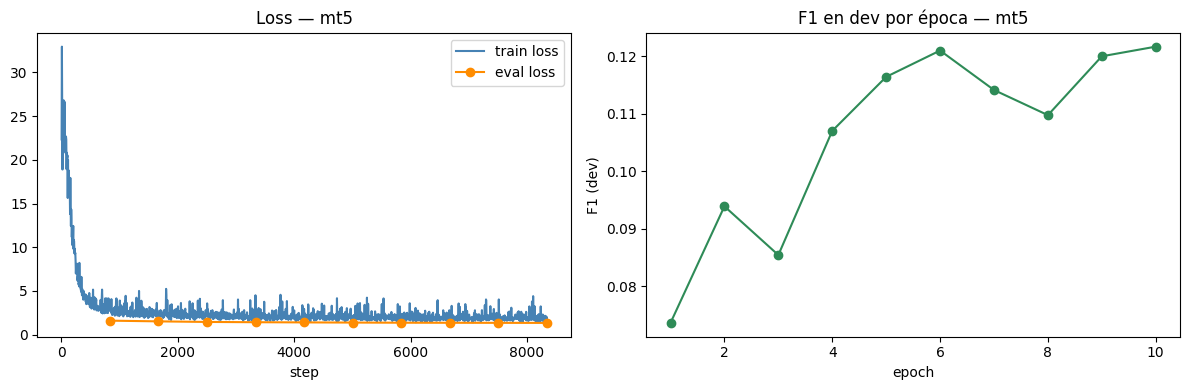

In [20]:
import matplotlib.pyplot as plt

history = trainer.state.log_history
train_loss = [(h["step"], h["loss"]) for h in history if "loss" in h]
eval_loss  = [(h["step"], h["eval_loss"]) for h in history if "eval_loss" in h]
eval_f1    = [(h["epoch"], h["eval_f1"]) for h in history if "eval_f1" in h]   # <- epoch

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(*zip(*train_loss), label="train loss", color="steelblue")
axes[0].plot(*zip(*eval_loss), label="eval loss", color="darkorange", marker="o")
axes[0].set_xlabel("step"); axes[0].set_title(f"Loss — {MODEL_KEY}"); axes[0].legend()

axes[1].plot(*zip(*eval_f1), color="seagreen", marker="o")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("F1 (dev)"); axes[1].set_title(f"F1 en dev por época — {MODEL_KEY}")

plt.tight_layout()
local_curve_path = f"eval_curves_{MODEL_KEY}.png"
plt.savefig(local_curve_path, dpi=150)
plt.savefig(str(OUTPUT_DIR / f"eval_curves_{MODEL_KEY}.png"), dpi=150)
plt.show()

## 10. Evaluación final en test

In [21]:
final_metrics = trainer.evaluate(tokenized_ds["test"])
print(f"Métricas FINE-TUNEADO ({MODEL_KEY}) en test:", final_metrics)

print("\n--- Comparación ---")
print("Baseline (dev):     ", baseline_metrics)
print("Fine-tuneado (test):", final_metrics)

Training Loss,Validation Loss,Epoch,Precision,Recall,F1
1.790222,1.434329,10,0.160600,0.094103,0.118671


Métricas FINE-TUNEADO (mt5) en test: {'eval_loss': 1.4343292713165283, 'eval_precision': 0.16059957173447537, 'eval_recall': 0.09410288582183186, 'eval_f1': 0.11867088607594937}

--- Comparación ---
Baseline (dev):      {'eval_loss': 16.677753448486328, 'eval_precision': 0.0, 'eval_recall': 0.0, 'eval_f1': 0.0}
Fine-tuneado (test): {'eval_loss': 1.4343292713165283, 'eval_precision': 0.16059957173447537, 'eval_recall': 0.09410288582183186, 'eval_f1': 0.11867088607594937}


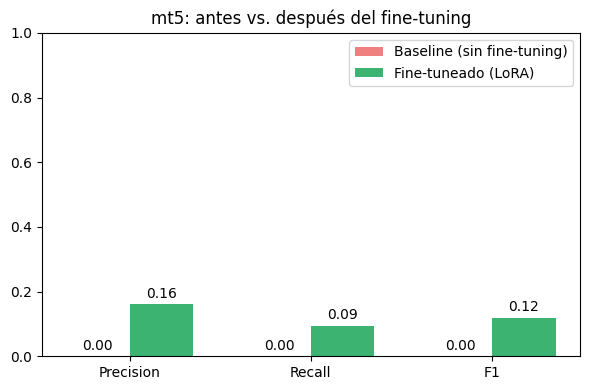

In [22]:
import numpy as np

metrics_names = ["precision", "recall", "f1"]
baseline_vals = [baseline_metrics[f"eval_{m}"] for m in metrics_names]
finetuned_vals = [final_metrics[f"eval_{m}"] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width/2, baseline_vals, width, label="Baseline (sin fine-tuning)", color="lightcoral")
ax.bar(x + width/2, finetuned_vals, width, label="Fine-tuneado (LoRA)", color="mediumseagreen")

ax.set_xticks(x); ax.set_xticklabels(["Precision", "Recall", "F1"])
ax.set_ylim(0, 1)
ax.set_title(f"{MODEL_KEY}: antes vs. después del fine-tuning")
for i, v in enumerate(baseline_vals): ax.text(i - width/2, v + 0.02, f"{v:.2f}", ha="center")
for i, v in enumerate(finetuned_vals): ax.text(i + width/2, v + 0.02, f"{v:.2f}", ha="center")
ax.legend()
plt.tight_layout()
local_bar_path = f"baseline_vs_finetuned_{MODEL_KEY}.png"
plt.savefig(local_bar_path, dpi=150)
plt.savefig(str(OUTPUT_DIR / f"baseline_vs_finetuned_{MODEL_KEY}.png"), dpi=150)
plt.show()

In [23]:
wandb.finish()

eval/f1,▁▄▃▆▇█▇▆███
eval/loss,█▆▄▃▃▂▂▁▁▁▄
eval/precision,▁▃▂▅▆▇▆▅▇▇█
eval/recall,▁▄▃▆▇█▇▆██▇
eval/runtime,▆▂▂▂▂▁▂▂▃▃█
eval/samples_per_second,▁▆▆▆▆█▆▆▄▅▄
eval/steps_per_second,▁▆▆▆▆█▆▆▄▅▅
train/epoch,▁▁▁▁▂▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇██
train/global_step,▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
train/grad_norm,▁█▁▁▇▁▁▁▁▂▂▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁
+2,...


## 11. Visualizar un ejemplo: antes vs. después del fine-tuning

Toman un ejemplo del set de test y comparan la predicción del modelo base contra la del
modelo fine-tuneado con LoRA, lado a lado.



In [24]:
import torch
from IPython.display import HTML, display
from transformers import AutoModelForTokenClassification

example = raw_ds["test"][0]

if cfg["arch"] == "token_classification":

    def predict_word_level(pred_model, tokens):
        """Predice tag por SUBTOKEN y lo colapsa a nivel de PALABRA
        (se queda con la predicción de la primera subpalabra de cada palabra,
        igual que se hizo al armar los labels de entrenamiento)."""
        inputs = tokenizer(tokens, is_split_into_words=True,
                            return_tensors="pt", truncation=True)
        inputs = inputs.to(pred_model.device)
        word_ids = inputs.word_ids(batch_index=0)
        with torch.no_grad():
            logits = pred_model(**inputs).logits
        pred_ids = logits.argmax(dim=-1)[0].tolist()

        word_preds, seen = [], set()
        for idx, wid in zip(pred_ids, word_ids):
            if wid is None or wid in seen:
                continue
            word_preds.append(id2label[idx])
            seen.add(wid)
        return word_preds


    base_model_raw = AutoModelForTokenClassification.from_pretrained(
        cfg["checkpoint"], num_labels=len(label_list),
        id2label=id2label, label2id=label2id
    )
    base_model_raw.eval()

    tokens = example["tokens"]
    true_tags = example["ner_tags"]
    baseline_tags = predict_word_level(base_model_raw, tokens)
    finetuned_tags = predict_word_level(model, tokens)

    assert len(tokens) == len(true_tags) == len(baseline_tags) == len(finetuned_tags), "Algo sigue sin alinear — revisar tokenización"

    def is_entity(tag):
        return tag.startswith("B-") or tag.startswith("I-")

    def render_row(label, tokens, tags, true_tags):

        html_output = f"<div style='margin-bottom:6px; max-width: 700px; display: flex; flex-wrap: wrap;'><b>{label}:</b><br>"
        for tok, tag, true in zip(tokens, tags, true_tags):
            t_ent, p_ent = is_entity(true), is_entity(tag)
            if t_ent and p_ent:
                color = "#b6e3a5"
            elif p_ent and not t_ent:
                color = "#f4a3a3"
            elif t_ent and not p_ent:
                color = "#f7c98d"
            else:
                color = "transparent"

            html_output += (f'<span style="background-color:{color};padding:1px 4px;'
                             f'border-radius:3px;margin-right:2px; display: inline-block; white-space: nowrap;" title="{tag}">{tok}</span>')
        html_output += "</div>"
        return html_output

    legend = ("<div style='margin-bottom:8px;font-size:0.9em'>"
              "<span style='background-color:#b6e3a5;padding:1px 6px;border-radius:3px'>Acierto</span> "
              "<span style='background-color:#f4a3a3;padding:1px 6px;border-radius:3px'>Falso positivo</span> "
              "<span style='background-color:#f7c98d;padding:1px 6px;border-radius:3px'>Se le escapó (FN)</span>"
              "</div>")

    html_out = legend
    html_out += render_row("Referencia (ground truth)", tokens, true_tags, true_tags)
    html_out += render_row("Baseline (sin fine-tuning)", tokens, baseline_tags, true_tags)
    html_out += render_row(f"Fine-tuneado ({MODEL_KEY} + LoRA)", tokens, finetuned_tags, true_tags)

    display(HTML(html_out))

else:
    inputs = tokenizer(example["input_text"], return_tensors="pt").to(model.device)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=64)
    print("Predicción (fine-tuneado):", tokenizer.decode(output_ids[0], skip_special_tokens=True))
    print("Referencia (ground truth):", example["target_text"])

[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Predicción (fine-tuneado): <extra_id_0> séptico [SEP] shock séptico [SEP] shock séptico [SEP] shock séptico [SEP] shock séptico [SEP] shock séptico [SEP] shock séptico [SEP] shock séptico [SEP] shock séptico [SEP] shock
Referencia (ground truth): shock séptico [SEP] CID


## 12. Guardar modelo

Con LoRA solo se guardan los pesos del adaptador (mucho más liviano que el modelo completo).



In [25]:
import json as _json

summary = {
    "model_key": MODEL_KEY,
    "checkpoint": cfg["checkpoint"],
    "baseline": {m: baseline_metrics[f"eval_{m}"] for m in metrics_names},
    "finetuned": {m: final_metrics[f"eval_{m}"] for m in metrics_names},
}
with open(OUTPUT_DIR / f"results_{MODEL_KEY}.json", "w") as f:
    _json.dump(summary, f, indent=2)

In [26]:
import shutil

save_dir_local = f"./saved-models/{MODEL_KEY}-distemist-lora"
model.save_pretrained(save_dir_local)
tokenizer.save_pretrained(save_dir_local)
print(f"Modelo guardado localmente en: {save_dir_local}")


destination_path_drive = BASE_DIR / "saved_models"
destination_path_drive.mkdir(exist_ok=True, parents=True)

shutil.copytree(save_dir_local, destination_path_drive / f"{MODEL_KEY}-distemist-lora", dirs_exist_ok=True)

print(f"Modelo copiado a Google Drive en: {destination_path_drive / f'{MODEL_KEY}-distemist-lora'}")

Modelo guardado localmente en: ./saved-models/mt5-distemist-lora
Modelo copiado a Google Drive en: /content/drive/MyDrive/TopicosIA/saved_models/mt5-distemist-lora
